In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("comfort_dataset.csv")

print(f"Załadowano dane: {df.shape[0]} wierszy i {df.shape[1]} kolumn.")
df.head()

Załadowano dane: 107583 wierszy i 70 kolumn.


C:\Users\kalin\AppData\Local\Temp\ipykernel_2436\3487011832.py:6: DtypeWarning: Columns (0: Cooling startegy_operation mode for MM buildings, 1: Heating strategy_building level, 2: Sex, 3: Air movement preference, 4: Thermal comfort, 5: Ta_m (F), 6: Humidity preference) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("comfort_dataset.csv")


,Publication (Citation),Data contributor,Year,Season,Koppen climate classification,Climate,City,Country,Building type,Cooling startegy_building level,...,Subject«s height (cm),Subject«s weight (kg),Blind (curtain),Fan,Window,Door,Heater,Outdoor monthly air temperature (C),Outdoor monthly air temperature (F),Database
0,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,162.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
1,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,154.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
2,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,173.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
3,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,167.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
4,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,178.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2


In [2]:
df.columns

Index(['Publication (Citation)', 'Data contributor', 'Year', 'Season',
       'Koppen climate classification', 'Climate', 'City', 'Country',
       'Building type', 'Cooling startegy_building level',
       'Cooling startegy_operation mode for MM buildings',
       'Heating strategy_building level', 'Age', 'Sex', 'Thermal sensation',
       'Thermal sensation acceptability', 'Thermal preference',
       'Air movement acceptability', 'Air movement preference',
       'Thermal comfort', 'PMV', 'PPD', 'SET', 'Clo', 'Met', 'activity_10',
       'activity_20', 'activity_30', 'activity_60', 'Air temperature (C)',
       'Air temperature (F)', 'Ta_h (C)', 'Ta_h (F)', 'Ta_m (C)', 'Ta_m (F)',
       'Ta_l (C)', 'Ta_l (F)', 'Operative temperature (C)',
       'Operative temperature (F)', 'Radiant temperature (C)',
       'Radiant temperature (F)', 'Globe temperature (C)',
       'Globe temperature (F)', 'Tg_h (C)', 'Tg_h (F)', 'Tg_m (C)', 'Tg_m (F)',
       'Tg_l (C)', 'Tg_l (F)', 'Relative humi

In [3]:
df_my = df[[ 'Air temperature (C)','Relative humidity (%)',  'Thermal comfort']]

In [4]:
df_my.info()

<class 'pandas.DataFrame'>
RangeIndex: 107583 entries, 0 to 107582
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Air temperature (C)    99911 non-null  float64
 1   Relative humidity (%)  97762 non-null  float64
 2   Thermal comfort        36335 non-null  object 
dtypes: float64(2), object(1)
memory usage: 2.5+ MB


In [5]:
df_my_without_na = df_my.dropna()

In [6]:
df_my_without_na.describe()

,Air temperature (C),Relative humidity (%)
count,27617.000000,27617.000000
mean,24.566035,48.475432
std,3.948479,15.491948
min,0.600000,10.000000
25%,22.400000,37.000000
50%,23.900000,48.100000
75%,26.500000,59.700000
max,47.000000,95.300000


In [7]:
df_my_without_na['Thermal comfort'] = pd.to_numeric(df_my_without_na['Thermal comfort'], errors='coerce')

df_my_without_na = df_my_without_na.dropna(subset=['Thermal comfort'])

In [8]:
df_my_without_na.info()

<class 'pandas.DataFrame'>
Index: 27616 entries, 0 to 104038
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Air temperature (C)    27616 non-null  float64
 1   Relative humidity (%)  27616 non-null  float64
 2   Thermal comfort        27616 non-null  float64
dtypes: float64(3)
memory usage: 863.0 KB


In [9]:
df_my_without_na['Thermal comfort'] = pd.cut(df_my_without_na['Thermal comfort'], 
                                   bins=8, 
                                   labels=[0, 1, 2, 3, 4, 5, 6, 7]).astype(int)

In [10]:
def generate_bus_data(base_df):
    df = base_df.copy()
    n = len(df)

    df['density'] = (df['Relative humidity (%)'] / 100) * 0.7 + np.random.normal(0.1, 0.1, n)
    df['density'] = df['density'].clip(0, 1)


    df['light'] = df['Air temperature (C)'] * 15 + np.random.uniform(50, 400, n)
    df['light'] = df['light'].clip(0, 1000)
    df['pressure'] = 1013 + np.random.normal(0, 2, n)

    return df

df_final = generate_bus_data(df_my_without_na)

In [11]:
def adjust_thermal_comfort(df):
    ideal_temp = 21
    base_comfort = 1.0 - (np.abs(df['Air temperature (C)'] - ideal_temp) / 15)

    crowd_effect = df['density'] * 0.6
    
    humidity_penalty = np.where(
        (df['Relative humidity (%)'] > 60) & (df['Air temperature (C)'] > 24),
        (df['Relative humidity (%)'] - 60) * 0.01, 
        0
    )
    
    stuffiness_effect = (df['density'] * (df['Relative humidity (%)'] / 100)) * 0.4

    sun_effect = np.where(
        df['Air temperature (C)'] > 22,
        (df['light'] / 1000) * 0.3,
        0
    )
    raw_comfort = (
        base_comfort 
        - crowd_effect 
        - humidity_penalty 
        - stuffiness_effect 
        - sun_effect
        + np.random.normal(0, 0.05, len(df))
    )
    

    
  
    df['Thermal comfort'] = pd.qcut(
        raw_comfort, 
        q=8, 
        labels=[0, 1, 2, 3, 4, 5, 6, 7]
    ).astype(int)
    
    return df

df_final = adjust_thermal_comfort(df_final)

In [12]:
df_final.columns

Index(['Air temperature (C)', 'Relative humidity (%)', 'Thermal comfort',
       'density', 'light', 'pressure'],
      dtype='str')

In [13]:
from sklearn.model_selection import train_test_split

X = df_final[['Air temperature (C)','Relative humidity (%)', 'density','light', 'pressure']]
y = df_final['Thermal comfort']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, recall_score, precision_score

In [15]:
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='reg:squarederror', 
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc =accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc} \n Recall: {recall} \n Precision {precision} \n F1 score {f1}")


Accuracy: 0.6822954380883418 
 Recall: 0.6823451584295837 
 Precision 0.6813866856698789 
 F1 score 0.6814791691082386


<Figure size 1000x600 with 0 Axes>

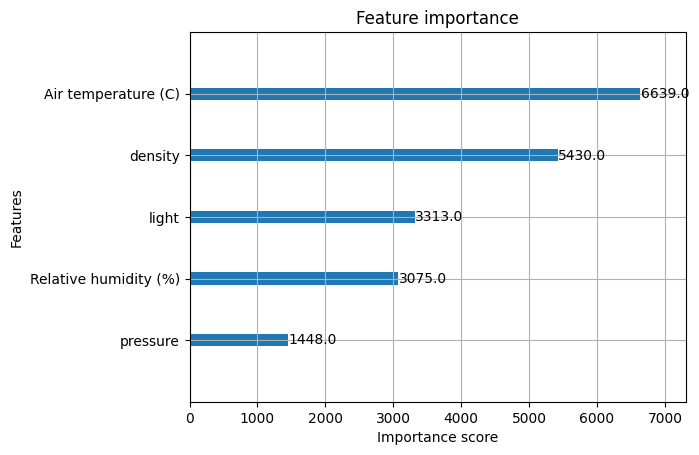

In [16]:
import matplotlib.pyplot as plt
import xgboost as xgb

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', title='Feature importance')
plt.show()

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       683
           1       0.81      0.80      0.81       693
           2       0.64      0.67      0.65       718
           3       0.52      0.52      0.52       711
           4       0.51      0.44      0.47       691
           5       0.52      0.54      0.53       658
           6       0.63      0.67      0.65       677
           7       0.87      0.87      0.87       693

    accuracy                           0.68      5524
   macro avg       0.68      0.68      0.68      5524
weighted avg       0.68      0.68      0.68      5524



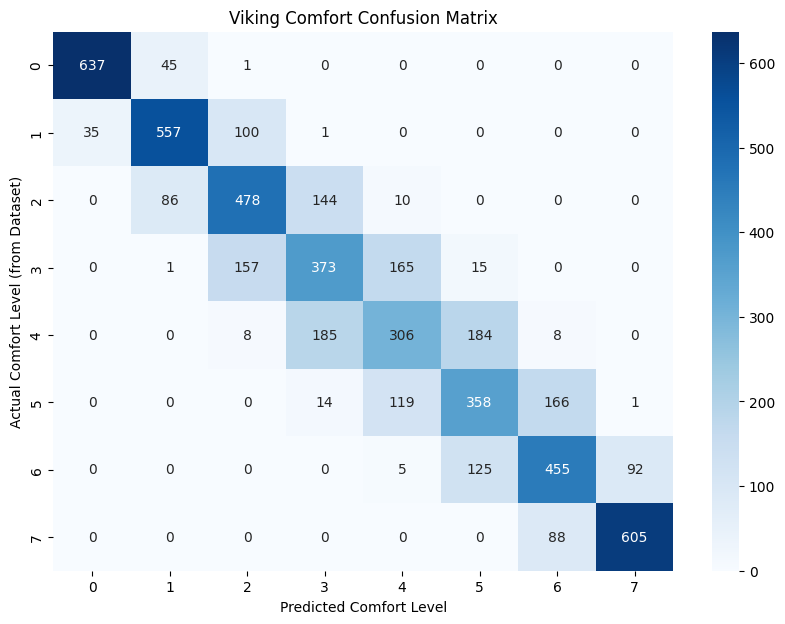

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0,1,2,3,4,5,6,7], 
            yticklabels=[0,1,2,3,4,5,6,7])
plt.xlabel('Predicted Comfort Level')
plt.ylabel('Actual Comfort Level (from Dataset)')
plt.title('Viking Comfort Confusion Matrix')
plt.show()

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    model = xgb.XGBClassifier(**param, 
                              tree_method = 'hist')
    score = cross_val_score(model, X_train, y_train, cv=3).mean()
    return score

study = optuna.create_study(study_name="example_xgboost_study", direction='maximize') 
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1) 

best_params = study.best_params
print(f"\nBest parameters: {best_params}")

In [ ]:
best_model = xgb.XGBClassifier(
    **best_params,
    tree_method='hist',
    objective='multi:softprob',
    num_class=8
)

best_model.fit(X_train, y_train)

y_pred = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc =accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc} \n Recall: {recall} \n Precision {precision} \n F1 score {f1}")

Accuracy: 0.663649529326575 
 Recall: 0.6641428089380772 
 Precision 0.6604320992957335 
 F1 score 0.6602359652044995


In [21]:
X_train

,Air temperature (C),Relative humidity (%),density,light,pressure
15415,22.8,58.1,0.400899,489.539222,1013.920448
73085,17.5,42.3,0.248186,618.514009,1011.282939
66895,39.8,22.3,0.183054,987.351640,1010.619463
103838,24.9,32.4,0.154649,726.459289,1013.397854
27634,18.2,53.0,0.488568,567.705314,1015.791552
...,...,...,...,...,...
84513,23.6,23.9,0.351003,683.148658,1014.260161
18647,26.3,44.5,0.454567,529.135412,1012.841100
13901,21.0,22.4,0.317628,529.527356,1013.426053
70201,25.0,67.4,0.551867,735.266270,1011.351875


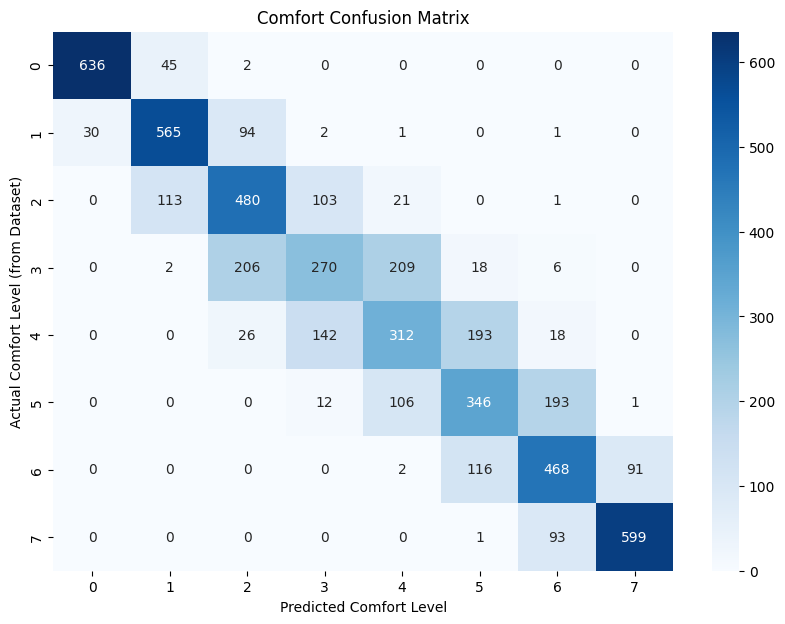

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0,1,2,3,4,5,6,7], 
            yticklabels=[0,1,2,3,4,5,6,7])
plt.xlabel('Predicted Comfort Level')
plt.ylabel('Actual Comfort Level (from Dataset)')
plt.title('Comfort Confusion Matrix')
plt.show()

In [23]:
import onnxmltools

from onnxmltools.convert.common.data_types import FloatTensorType

best_model.get_booster().feature_names = None
initial_types = [('float_input', FloatTensorType([1, X.shape[1]]))]

onnx_model = onnxmltools.convert_xgboost(best_model, initial_types=initial_types)

with open("xgboost_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

In [24]:
import onnxruntime as rt
import numpy as np

sess = rt.InferenceSession("xgboost_model.onnx")

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name

dummy_data = np.array([[25.5, 80.0, 0.9, 650, 1013.2]], dtype=np.float32)

pred_onx = sess.run([label_name], {input_name: dummy_data})

print(f"Predicted Class: {pred_onx[0]}")

Predicted Class: [0]


In [25]:
df_final.to_csv("data.csv", index=False)